# Quora Duplicate Question Detection

## Classical Machine Learning Models

This notebook trains and evaluates classical supervised models using the
preprocessed datasets created in `01_data_preparation_eda.ipynb`.

## Project Setup and Imports

In [ ]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

In [ ]:
# Colab only: uncomment when running the notebook in Google Colab
# %cd "/content/drive/MyDrive/ML Projects/quora-duplicate-question-detection"

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: g:\My Drive\ML Projects\quora-duplicate-question-detection


In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from src.config import (
    processed_train_file,
    processed_test_file,
    results_file,
)

from src.features import (
    build_word_weights,
    create_basic_pair_features,
    create_content_overlap_features,
)

from src.evaluation import (
    evaluate_binary_classifier,
    save_experiment_result,
)


In [3]:
RANDOMSEED = 42

## TF-IDF + Logistic Regression

### Load Preprocessed Data

In [4]:
processed_train = pd.read_parquet(
    processed_train_file
)

processed_test = pd.read_parquet(
    processed_test_file
)

train_data = (
    processed_train[
        processed_train["split"] == "train"
    ]
    .copy()
)

valid_data = (
    processed_train[
        processed_train["split"] == "valid"
    ]
    .copy()
)

print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", processed_test.shape)

Train shape: (258743, 11)
Validation shape: (64686, 11)
Test shape: (80858, 10)


In [5]:
y_train = train_data["is_duplicate"].astype(int)
y_valid = valid_data["is_duplicate"].astype(int)

### TF-IDF Feature Construction

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="word",
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

In [7]:
train_q1 = train_data["question1_tfidf"].fillna("")
train_q2 = train_data["question2_tfidf"].fillna("")

valid_q1 = valid_data["question1_tfidf"].fillna("")
valid_q2 = valid_data["question2_tfidf"].fillna("")

In [ ]:
train_corpus = pd.concat(
    [
        train_q1,
        train_q2
    ],
    ignore_index=True
)

tfidf_vectorizer.fit(train_corpus)

In [9]:
print(
    f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}"
)

Vocabulary size: 342,949


In [10]:
X_train_q1 = tfidf_vectorizer.transform(train_q1)
X_train_q2 = tfidf_vectorizer.transform(train_q2)

X_valid_q1 = tfidf_vectorizer.transform(valid_q1)
X_valid_q2 = tfidf_vectorizer.transform(valid_q2)

In [11]:
X_train_diff = abs(X_train_q1 - X_train_q2)
X_valid_diff = abs(X_valid_q1 - X_valid_q2)

X_train_product = X_train_q1.multiply(X_train_q2)
X_valid_product = X_valid_q1.multiply(X_valid_q2)

X_train_pair = hstack(
    [X_train_diff, X_train_product],
    format="csr"
)

X_valid_pair = hstack(
    [X_valid_diff, X_valid_product],
    format="csr"
)

print("Train pair shape:", X_train_pair.shape)
print("Validation pair shape:", X_valid_pair.shape)

Train pair shape: (258743, 685898)
Validation pair shape: (64686, 685898)


### Logistic Regression Training and Evaluation

In [12]:
tfidf_lr = LogisticRegression(
    solver="saga",
    max_iter=300,
    random_state=RANDOMSEED,
    verbose=1
)

In [ ]:
tfidf_lr.fit(
    X_train_pair,
    y_train
)

valid_pred = tfidf_lr.predict(X_valid_pair)
valid_proba = tfidf_lr.predict_proba(X_valid_pair)[:, 1]

Model: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

           0     0.8372    0.8977    0.8664     40804
           1     0.8005    0.7017    0.7478     23882

    accuracy                         0.8253     64686
   macro avg     0.8189    0.7997    0.8071     64686
weighted avg     0.8236    0.8253    0.8226     64686

accuracy: 0.8253
precision: 0.8005
recall: 0.7017
f1: 0.7478
roc_auc: 0.9039
log_loss: 0.3893


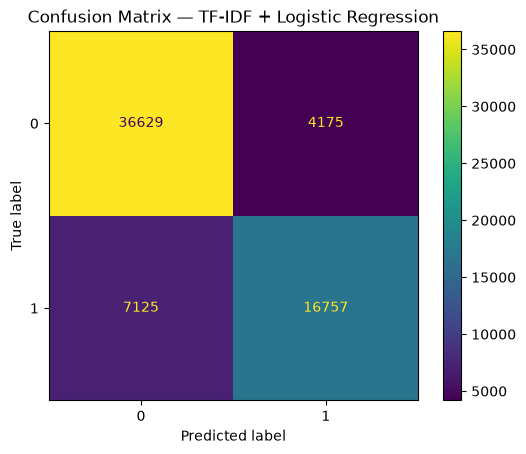

In [14]:
tfidf_lr_metrics = evaluate_binary_classifier(
    model_name="TF-IDF + Logistic Regression",
    y_true=y_valid,
    y_pred=valid_pred,
    y_proba=valid_proba,
)

### Conclusions

- TF-IDF combined with Logistic Regression provides a strong supervised baseline for duplicate-question detection.
- The model achieved a validation ROC-AUC of approximately **0.90**, demonstrating a strong ability to distinguish duplicate and non-duplicate question pairs.
- Precision and recall are reasonably balanced, resulting in a positive-class F1-score of approximately **0.75**.
- The use of both unigram and bigram TF-IDF features allowed the model to capture both lexical overlap and short phrase similarity between questions.
- This model will serve as the baseline for comparison with more advanced approaches in the subsequent experiments.

### Experiment Results

The validation metrics of each model experiment are stored in a shared results
table. Re-running the same experiment replaces its previous result instead of
creating duplicate rows.

In [17]:
logreg_result_row = {
    "experiment_id": "tfidf_logreg_baseline",
    "evaluation_split": "validation",
    "feature_set": (
        "TF-IDF word 1-2 grams: "
        "absolute difference + element-wise product"
    ),
    "threshold": 0.5,
    **tfidf_lr_metrics,
}

model_results = save_experiment_result(
    result_row=logreg_result_row,
    results_file=results_file
)

Results saved to: g:\My Drive\ML Projects\quora-duplicate-question-detection\reports\model_results.csv


## Gradient Boosting with Engineered Features

### Basic Lexical and Length Features

For each question pair, we construct interpretable numerical features describing:

- question lengths in characters and words;
- differences and ratios between question lengths;
- the number and proportion of shared words;
- whether the questions begin or end with the same word;
- whether the processed question texts are exactly equal.

The features are constructed symmetrically so that swapping `question1` and
`question2` does not change their values.

In [20]:
X_train_manual = create_basic_pair_features(
    train_data
)

X_valid_manual = create_basic_pair_features(
    valid_data
)

print(
    "Train manual features shape:",
    X_train_manual.shape,
)

print(
    "Validation manual features shape:",
    X_valid_manual.shape,
)

display(X_train_manual.head())

Train manual features shape: (258743, 14)
Validation manual features shape: (64686, 14)


,min_char_count,max_char_count,char_count_diff,char_count_ratio,min_word_count,max_word_count,word_count_diff,word_count_ratio,common_word_count,word_union_count,word_jaccard,same_first_word,same_last_word,exact_text_match
0,47,81,34,0.580247,9,14,5,0.642857,1,20,0.050000,0,0,0
1,55,62,7,0.887097,8,9,1,0.888889,4,11,0.363636,1,1,0
2,32,78,46,0.410256,5,15,10,0.333333,1,17,0.058824,0,0,0
3,42,51,9,0.823529,9,11,2,0.818182,6,14,0.428571,1,0,0
4,68,159,91,0.427673,11,31,20,0.354839,7,33,0.212121,1,0,0


In [21]:
print(
    "Missing values:",
    X_train_manual.isna().sum().sum(),
)

display(
    X_train_manual.describe().T
)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
min_char_count,258743.0,49.755070,22.963884,1.000000,35.000000,44.000000,59.000000,353.0
max_char_count,258743.0,69.899232,36.303188,2.000000,46.000000,60.000000,85.000000,1169.0
char_count_diff,258743.0,20.144162,25.679464,0.000000,5.000000,12.000000,26.000000,1080.0
char_count_ratio,258743.0,0.753362,0.187905,0.006711,0.631579,0.790000,0.910925,1.0
min_word_count,258743.0,9.217664,4.141853,1.000000,7.000000,8.000000,11.000000,64.0
max_word_count,258743.0,12.906873,6.743241,1.000000,9.000000,11.000000,15.000000,237.0
word_count_diff,258743.0,3.689209,4.852103,0.000000,1.000000,2.000000,5.000000,223.0
word_count_ratio,258743.0,0.758523,0.192738,0.027027,0.636364,0.800000,0.900000,1.0
common_word_count,258743.0,4.511801,3.101389,0.000000,2.000000,4.000000,6.000000,41.0
word_union_count,258743.0,16.612009,7.941044,1.000000,11.000000,15.000000,20.000000,154.0


In [22]:
train_tfidf_cosine = np.asarray(
    X_train_q1
    .multiply(X_train_q2)
    .sum(axis=1)
).ravel().astype(np.float32)

valid_tfidf_cosine = np.asarray(
    X_valid_q1
    .multiply(X_valid_q2)
    .sum(axis=1)
).ravel().astype(np.float32)

In [23]:
X_train_boosting = X_train_manual.copy()
X_valid_boosting = X_valid_manual.copy()

X_train_boosting[
    "tfidf_cosine_similarity"
] = train_tfidf_cosine

X_valid_boosting[
    "tfidf_cosine_similarity"
] = valid_tfidf_cosine

print("Train shape:", X_train_boosting.shape)
print("Validation shape:", X_valid_boosting.shape)

Train shape: (258743, 15)
Validation shape: (64686, 15)


In [24]:
word_weights = build_word_weights(
    train_data
)

print(
    "Number of weighted words:",
    len(word_weights),
)

Number of weighted words: 70539


In [ ]:
%%time

train_content_features = (
    create_content_overlap_features(
        train_data,
        word_weights,
    )
)

valid_content_features = (
    create_content_overlap_features(
        valid_data,
        word_weights,
    )
)

In [26]:
for column in train_content_features.columns:
    X_train_boosting[column] = (
        train_content_features[column]
    )

    X_valid_boosting[column] = (
        valid_content_features[column]
    )

In [27]:
xgb_model = XGBClassifier(
    n_estimators=2500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    random_state=RANDOMSEED,
    n_jobs=-1,
)

In [ ]:
xgb_model.fit(
    X_train_boosting,
    y_train,
    eval_set=[
        (X_train_boosting, y_train),
        (X_valid_boosting, y_valid),
    ],
    verbose=50,
)

Model: XGBoost + Engineered Features

              precision    recall  f1-score   support

           0     0.8251    0.7947    0.8096     40804
           1     0.6700    0.7122    0.6905     23882

    accuracy                         0.7643     64686
   macro avg     0.7476    0.7535    0.7501     64686
weighted avg     0.7679    0.7643    0.7656     64686

accuracy: 0.7643
precision: 0.6700
recall: 0.7122
f1: 0.6905
roc_auc: 0.8529
log_loss: 0.4371


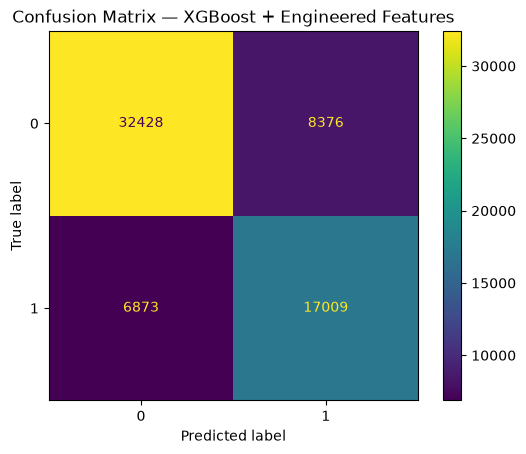

In [30]:
xgb_model_pred = xgb_model.predict(X_valid_boosting)

xgb_model_proba = xgb_model.predict_proba(X_valid_boosting)[:, 1]

xgb_model_metrics = evaluate_binary_classifier(
    model_name=(
        "XGBoost + Engineered Features"
    ),
    y_true=y_valid,
    y_pred=xgb_model_pred,
    y_proba=xgb_model_proba,
)



### Experiment Results

In [31]:
xgb_result_row = {
    "experiment_id": "xgboost_engineered_features",
    "evaluation_split": "validation",
    "feature_set": (
        "14 symmetric lexical and length features + "
        "TF-IDF cosine similarity + "
        "content-word overlap + "
        "weighted content-word overlap"
    ),
    "threshold": 0.5,
    **xgb_model_metrics,
}

model_results = save_experiment_result(
    result_row=xgb_result_row,
    results_file=results_file,
)

Results saved to: g:\My Drive\ML Projects\quora-duplicate-question-detection\reports\model_results.csv


In [32]:
model_results_display = model_results.copy()

numeric_columns = (
    model_results_display
    .select_dtypes(include="number")
    .columns
)

model_results_display[
    numeric_columns
] = model_results_display[
    numeric_columns
].round(4)

display(
    model_results_display.sort_values(
        by="log_loss"
    )
)

,experiment_id,evaluation_split,feature_set,threshold,model,accuracy,precision,recall,f1,roc_auc,log_loss
1,tfidf_logreg_baseline,validation,TF-IDF word 1-2 grams: absolute difference + e...,0.50,TF-IDF + Logistic Regression,0.8253,0.8005,0.7017,0.7478,0.9039,0.3893
2,xgboost_engineered_features,validation,14 symmetric lexical and length features + TF-...,0.50,XGBoost + Engineered Features,0.7643,0.6700,0.7122,0.6905,0.8529,0.4371
0,bert_mean_pooling_cosine,validation,Mean-pooled bert-base-uncased embeddings + cos...,0.83,BERT Embeddings + Cosine Similarity,0.6513,0.5167,0.8559,0.6444,0.7455,NaN


### XGBoost Conclusions

- The XGBoost model achieved a validation log loss of approximately **0.437** and a ROC-AUC of approximately **0.85**.
- Adding content-word overlap and frequency-weighted word overlap features substantially improved the boosting model.
- XGBoost achieved slightly higher recall for the duplicate class than Logistic Regression, but its precision, F1-score, ROC-AUC, and log loss were lower.
- TF-IDF with Logistic Regression remained the strongest classical model. The high-dimensional TF-IDF representation preserved more detailed lexical information than the compact set of engineered features used by XGBoost.